# 3rd SESBC Summer School Exercises

2026-08-19

Romaric Duvignau, duvignau@chalmers.se

Here below a couple of small exercises to get accustomed to the basic functionalities of the PyPESOL library.



## Preliminaries -- Have first a Quick Look at the Data!

For those exercises, we will use prices of 2023. 

Have a look at those prices:

In [45]:
# Re-execute this block at first and upon every kernel restart

from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"] = (20,3)

from optimizer import *

opt = Optimizer.from_folder2("data_exercises")

Let's have a quick look over the data.

For the exercises, we will use 1 year of historical hourly data for 1 household, the electricity prices in South-West Sweden from 2023, and a realistic solar profile for the same region. 

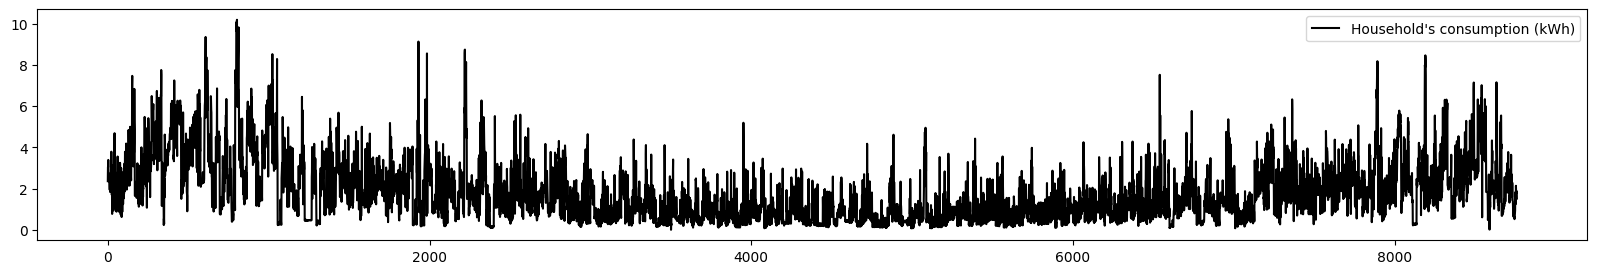

np.float64(1.7587218550228336)

In [35]:
plt.plot(opt.cons[0], color="black", label="Household's consumption (kWh)")
plt.legend()
plt.show()

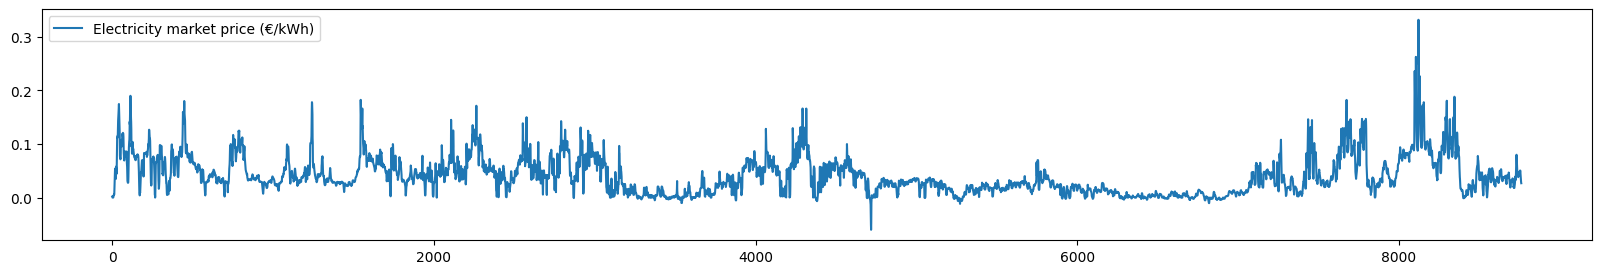

8761


In [9]:
plt.plot(opt.price, label="Electricity market price (€/kWh)")
plt.legend()
plt.show()

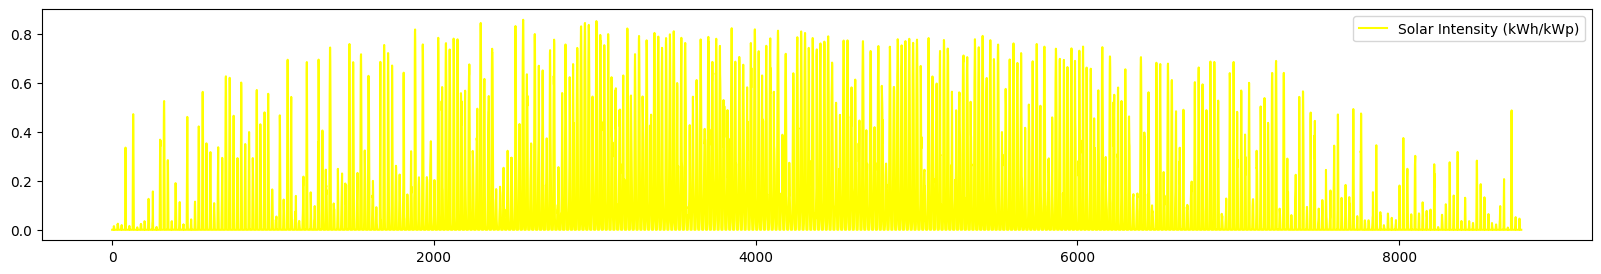

8760

In [12]:
plt.plot(opt.sun[0], color="yellow", label="Solar Intensity (kWh/kWp)")
plt.legend()
plt.show()

In [14]:
sum(opt.price)/len(opt.price)

np.float64(0.03997219609633593)

Let's also have a look over the optimizer default's parameters:

In [29]:
opt.tax # Taxation level over market price (1.25 = 25% added tax)

1.25

In [19]:
opt.el_tax # Electricity tax (€/kWh)

0.069066

In [20]:
opt.el_net # Electricity surplus bonus (€/kWh)

0.0057555

By default the considered household has no PV nor battery system, this can be checked in the optimizer:

In [27]:
print(opt.pv[0])

0.0


In [28]:
print(opt.battery[0])

0.0


## Exercise 1. PV and Battery Sizing

### a. Check PV and Battery Income 

Let's variate the PV size for the studied household and observe the yearly electricity cost. Note that here, since the user has no battery, the opptimization solver is trivial and instant to run.

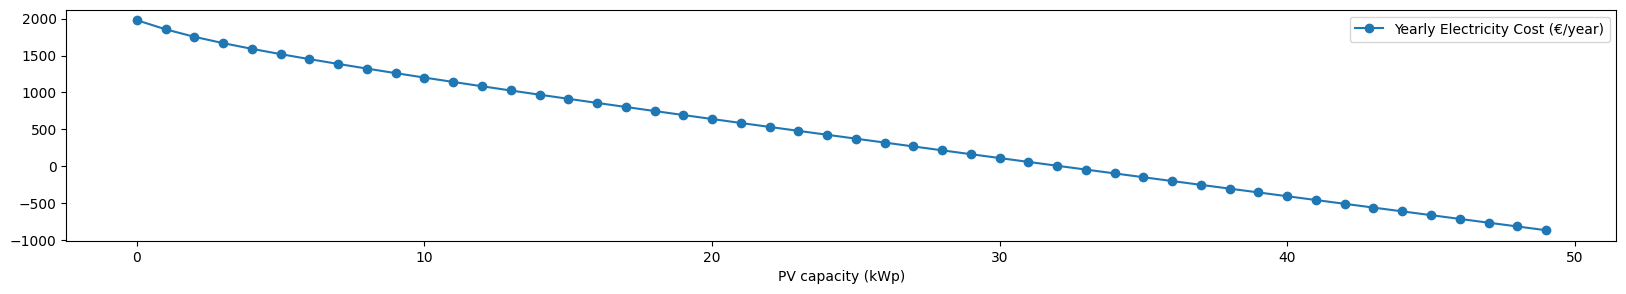

In [17]:
yearly_costs = []
for pv_size in range(50):
    opt.pv[0] = pv_size
    yearly_costs.append(opt.optimize(0))

plt.plot(yearly_costs, marker='o', label="Yearly Electricity Cost (€/year)")
plt.xlabel("PV capacity (kWp)")
plt.legend()
plt.show()

Now let's check how the addition of a battery system alone (no PV) would benefit the user. Even with a battery alone, the LP-solver is triggered to calculate optimal yearly cost as decisions are required (when to charge and discharge the battery). A single yearly costs computation takes around 1-2 seconds on a usual laptop. 
We will calculate the costs for battery size 0, 5, 10, ... till 50 kWh.

Calculating yearly cost for battery size: 0
Calculating yearly cost for battery size: 5
Calculating yearly cost for battery size: 10
Calculating yearly cost for battery size: 15
Calculating yearly cost for battery size: 20
Calculating yearly cost for battery size: 25
Calculating yearly cost for battery size: 30
Calculating yearly cost for battery size: 35
Calculating yearly cost for battery size: 40
Calculating yearly cost for battery size: 45


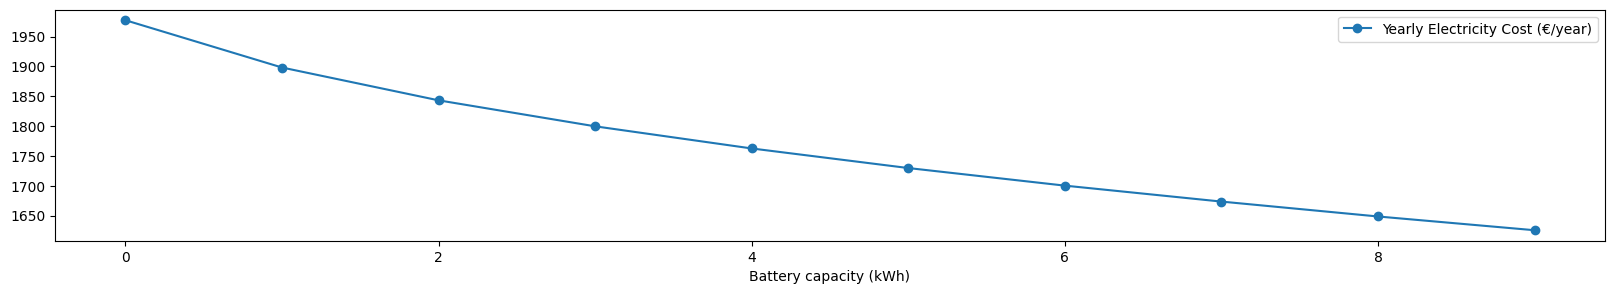

[1977.4033057805707, 1898.18723, 1843.21041, 1799.68, 1762.59108, 1729.78411, 1700.31968, 1673.60088, 1648.6405, 1625.61389]


In [72]:
opt.pv[0] = 0 # reset PV capacity

yearly_costs = []
for battery_size in range(0, 50, 5):
    print("Calculating yearly cost for battery size:", battery_size)
    opt.battery[0] = battery_size
    yearly_costs.append(opt.optimize(0))

plt.plot(yearly_costs, marker='o', label="Yearly Electricity Cost (€/year)")
plt.xlabel("Battery capacity (kWh)")
plt.legend()
plt.show()

### First exercise

Calculate the yearly costs for a combined PV-battery system of size (0,0), (1,2), (2,4), ... (10,20), and plot the income (€/year) generated after installing the combined system.

Calculating yearly cost for pv size 0  and battery size: 0
Calculating yearly cost for pv size 1  and battery size: 2
Calculating yearly cost for pv size 2  and battery size: 4
Calculating yearly cost for pv size 3  and battery size: 6
Calculating yearly cost for pv size 4  and battery size: 8
Calculating yearly cost for pv size 5  and battery size: 10
Calculating yearly cost for pv size 6  and battery size: 12
Calculating yearly cost for pv size 7  and battery size: 14
Calculating yearly cost for pv size 8  and battery size: 16
Calculating yearly cost for pv size 9  and battery size: 18
Calculating yearly cost for pv size 10  and battery size: 20


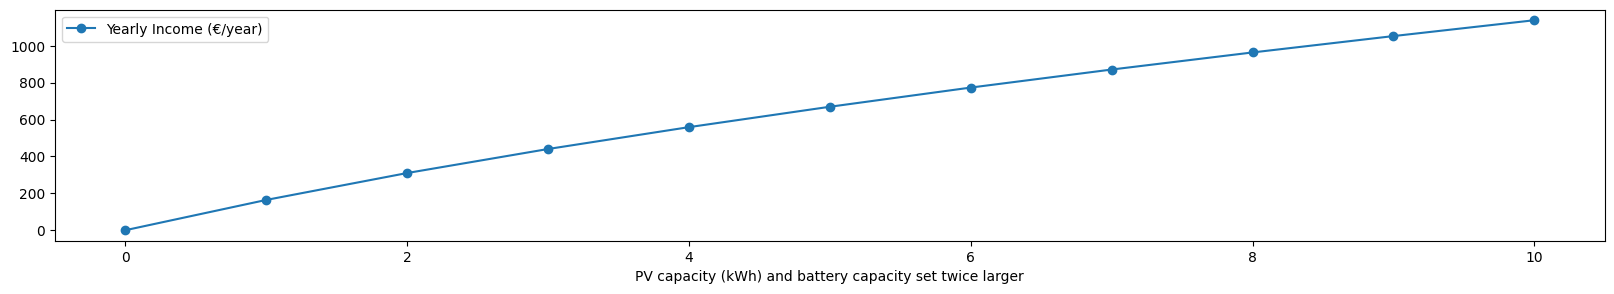

In [24]:
opt.pv[0] = 0       # reset PV capacity
opt.battery[0] = 0  # reset battery capacity

base_cost = opt.optimize(0)

yearly_income = []
pv_sizes = []

for pv_size in range(0,11):
    pv_sizes.append(pv_size)
    battery_size = 2 * pv_size
    print("Calculating yearly cost for pv size", pv_size, " and battery size:", battery_size)

    # Set PV and battery capacities
    opt.pv[0] = pv_size
    opt.battery[0] = battery_size

    # Optimize and calculate income compared with base cost
    yearly_income.append(base_cost - opt.optimize(0))

plt.plot(pv_sizes, yearly_income, marker='o', label="Yearly Income (€/year)")
plt.xlabel("PV capacity (kWh) and battery capacity set twice larger")
plt.legend()
plt.show()

# b. Calculate the Most Profitable PV-Battery sizes

In the second part of this exercise, we will calculate the best size for the PV and battery system based on simplified investment calculation.

The cost of the PV installation is set to 1100€ per kWp and it is paid back over 25 years at a rate of 2.5%.

The cost of the Battery installation is set to 400€ per kWh and it is paid back over 15 years at a rate of 2.5%.

Use the following simplified function to calculate yearly payment.

In [16]:
# loan_amount in €, rate as annual fraction, duration in months
def calculate_yearly_loan_payment(loan_amount, rate, duration):
    monthly_rate = rate / 12
    pmt = loan_amount * (
        monthly_rate /
        (1 - (1 + monthly_rate)**(-duration))
    )
    return pmt * 12

# Example usage for 10 kWp PV
yearly_rate = 0.025
pv_duration = 25*12
pv_cost = 1100
pv_size = 10

round(calculate_yearly_loan_payment(pv_cost*pv_size, yearly_rate, pv_duration),2)

592.17

In [14]:
# Example with a 20 kWh battery
battery_cost = 400
battery_size = 2
battery_duration = 15*12

round(calculate_yearly_loan_payment(battery_cost*pv_size*battery_size, yearly_rate, battery_duration),2)

640.12

To search for the best sizing, you can start by testing similar capacities as used in the previous exercise. Then, you can do a grid search or another search method.

Calculating yearly cost for pv size 0  and battery size: 0
Calculating yearly cost for pv size 1  and battery size: 1
Calculating yearly cost for pv size 2  and battery size: 2
Calculating yearly cost for pv size 3  and battery size: 3
Calculating yearly cost for pv size 4  and battery size: 4
Calculating yearly cost for pv size 5  and battery size: 5
Calculating yearly cost for pv size 6  and battery size: 6
Calculating yearly cost for pv size 7  and battery size: 7
Calculating yearly cost for pv size 8  and battery size: 8
Calculating yearly cost for pv size 9  and battery size: 9
Calculating yearly cost for pv size 10  and battery size: 10
Calculating yearly cost for pv size 11  and battery size: 11
Calculating yearly cost for pv size 12  and battery size: 12
Calculating yearly cost for pv size 13  and battery size: 13
Calculating yearly cost for pv size 14  and battery size: 14
Calculating yearly cost for pv size 15  and battery size: 15
Calculating yearly cost for pv size 16  and 

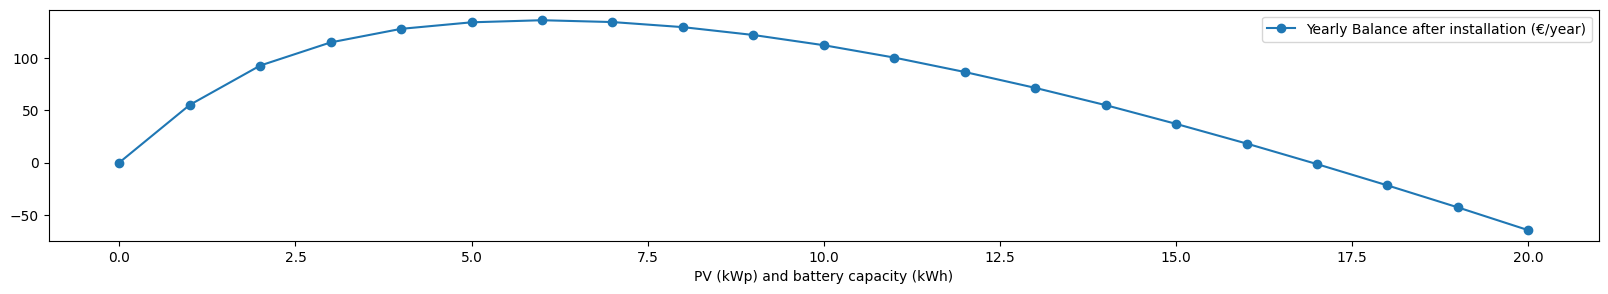

In [25]:
yearly_income = []
pv_sizes = []

def calculate_yearly_benefit(opt, pv_size, battery_size):
    opt.pv[0] = 0       # reset PV capacity
    opt.battery[0] = 0  # reset battery capacity
    base_cost = opt.optimize(0)
    
    pv_payment = round(calculate_yearly_loan_payment(pv_cost*pv_size, yearly_rate, pv_duration),2)
    battery_payment = round(calculate_yearly_loan_payment(battery_cost*battery_size, yearly_rate, battery_duration),2)
    year_invest = pv_payment + battery_payment
    #print("Yearly PV payment", pv_payment, " and battery payment", battery_payment, "total:", year_invest)

    # Set PV and battery capacities
    opt.pv[0] = pv_size
    opt.battery[0] = battery_size

    # Optimize and calculate income compared with base cost while accounting for the investment reimbursements
    return round( base_cost - (opt.optimize(0)+year_invest), 2)
    

for pv_size in range(0,21):
    pv_sizes.append(pv_size)
    battery_size = pv_size
    print("Calculating yearly cost for pv size", pv_size, " and battery size:", battery_size)

    # Optimize and calculate income compared with base cost while accounting for the investment reimbursements
    yearly_income.append(calculate_yearly_benefit(opt, pv_size, battery_size))

plt.plot(pv_sizes, yearly_income, marker='o', label="Yearly Balance after installation (€/year)")
plt.xlabel("PV (kWp) and battery capacity (kWh)")
plt.legend()
plt.show()

In [26]:
# best found PV size and battery system under the current hypothesis
i = np.argmax(yearly_income)
print(f"Best PV size {pv_sizes[i]} kWp, Best Battery size {pv_sizes[i]} kWh")

Best PV size 6 kWp, Best Battery size 6 kWh


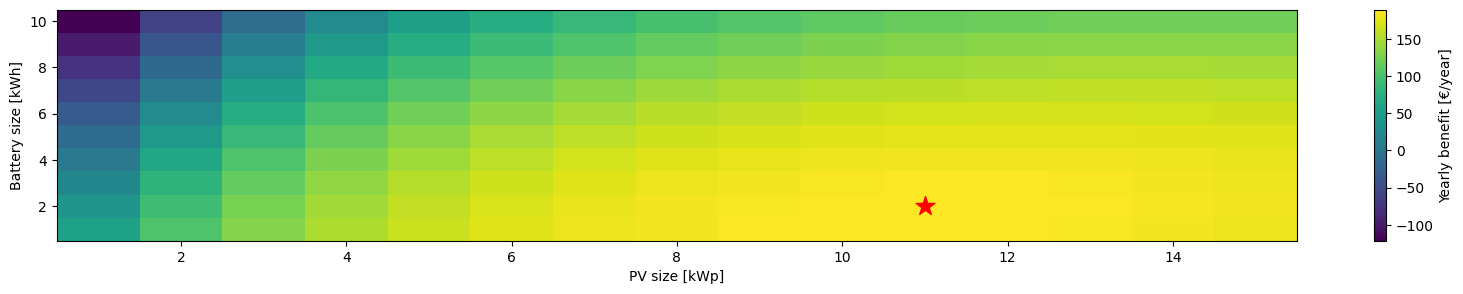

Best: 11.0 kWp PV, 2.0 kWh battery


In [22]:
def grid_search(pv_sizes, battery_sizes):
    benefit = np.array([
        [calculate_yearly_benefit(opt, pv, bat) for pv in pv_sizes]
        for bat in battery_sizes
    ])
    
    i, j = np.unravel_index(np.argmax(benefit), benefit.shape)
    
    plt.pcolormesh(pv_sizes, battery_sizes, benefit, shading="auto")
    plt.colorbar(label="Yearly benefit [€/year]")
    plt.scatter(pv_sizes[j], battery_sizes[i], marker="*", s=200, c="red")
    plt.xlabel("PV size [kWp]")
    plt.ylabel("Battery size [kWh]")
    plt.show()
    
    return i,j

# 1st coarse grid search around (3,6) PV-battery capacity

pv_sizes = np.arange(1, 15.1, 1)
battery_sizes = np.arange(1, 10.1, 1)

i,j = grid_search(pv_sizes, battery_sizes)
print(f"Best: {pv_sizes[j]} kWp PV, {battery_sizes[i]} kWh battery")

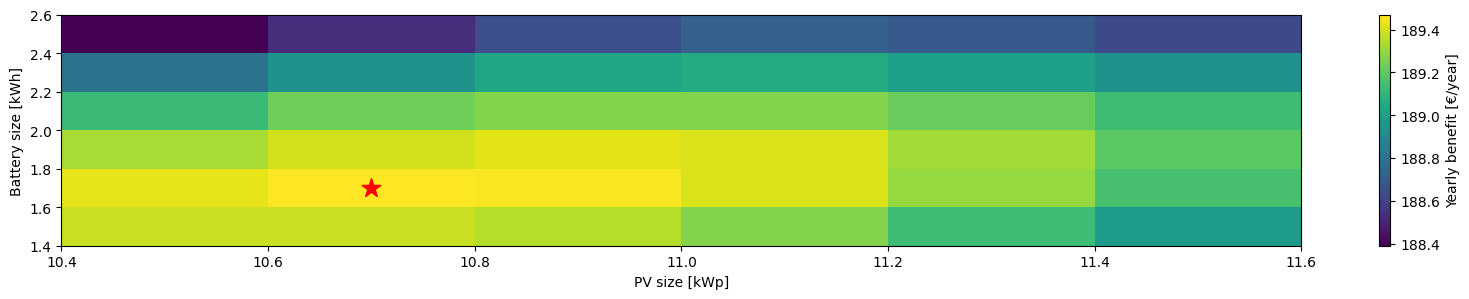

Best: 10.7 kWp PV, 1.7 kWh battery


In [23]:
# 1st grid search tells us we need more PV and less battery capacity
# 2nd more fine-grain grid search around first optimal region around 4.5 kWp PV, 6.0 kWh battery

pv_sizes = np.arange(10.5, 11.51, 0.2)
battery_sizes = np.arange(1.5, 2.51, 0.2)

i,j = grid_search(pv_sizes, battery_sizes)
print(f"Best: {pv_sizes[j]} kWp PV, {battery_sizes[i]} kWh battery")

## Exercise 2. Utra-smart charging aka when to charge your EV?

In this exercise, we try to infer when to charge an EV in a simplified scenario.

### Part1 -- Forecasting future data

We will use meta's module "prophet" to produce a simple forecast of consumption and sun data. For prices, it is reasonable to assume we have day-ahead tariffs available.


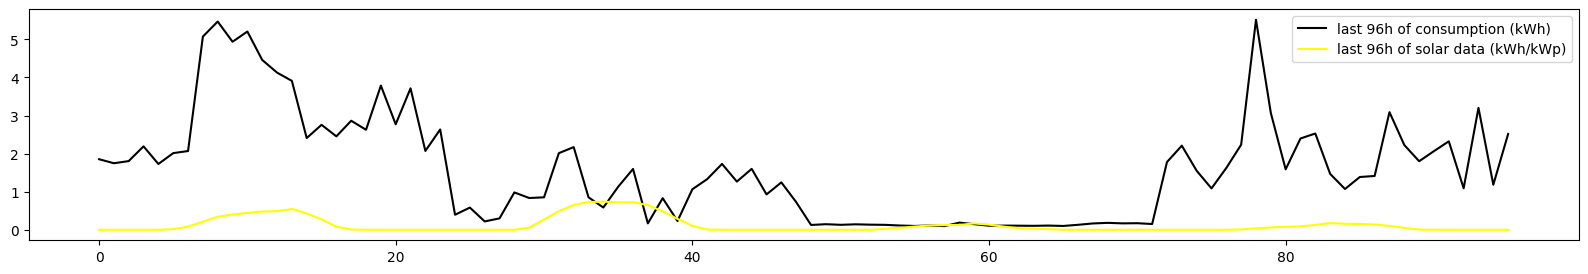

In [41]:
# day of the year when to test (data from the beginning of the year will be used for the forecast)
day = 102

# time slot
t = day * 24

# show current last 5 days of data
plt.plot(opt.cons[0][t-96:t], color="black", label="last 96h of consumption (kWh)")
plt.plot(opt.sun[0][t-96:t], color="yellow", label="last 96h of solar data (kWh/kWp)")
plt.legend()
plt.show()

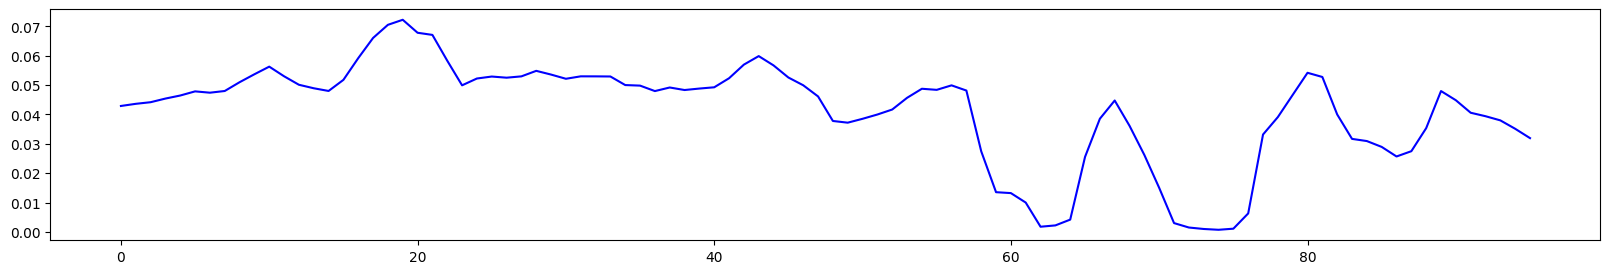

In [19]:
plt.plot(opt.price[t-96:t], color="blue", label="last 96h of price data (€/kWh)")

12:56:23 - cmdstanpy - INFO - Chain [1] start processing
12:56:23 - cmdstanpy - INFO - Chain [1] done processing
12:56:23 - cmdstanpy - INFO - Chain [1] start processing
12:56:23 - cmdstanpy - INFO - Chain [1] done processing
12:56:23 - cmdstanpy - INFO - Chain [1] start processing
12:56:23 - cmdstanpy - INFO - Chain [1] done processing


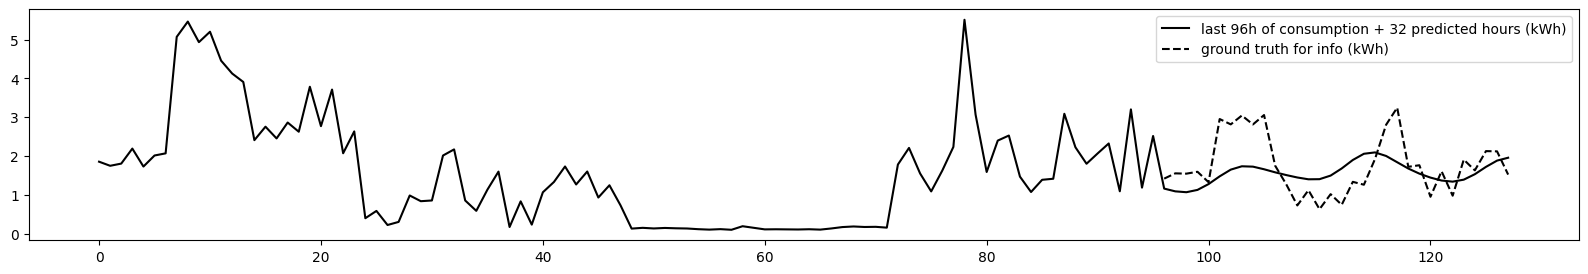

In [46]:
from predictor import *

# previous hours (used for the plots only)
prev_hours = 96

# forecasting window in hours
horizon = 32

# forget any data past that hour
opt2 = opt.hours(0,t)

extend_optimizer_with_predicted_values(opt2, h = 0, forecast_window = horizon)

# set exact prices instead of prediction
opt2.price[t:] = opt.price[t:t+horizon]

# show current day of data
plt.plot(opt2.cons[0][-prev_hours-horizon:], color="black", label=f"last {prev_hours}h of consumption + {horizon} predicted hours (kWh)")
plt.plot(range(prev_hours,prev_hours+horizon), opt.cons[0][t:t+horizon], color="black", linestyle='--', label=f"ground truth for info (kWh)")
plt.legend()
plt.show()


### Part2 -- Customizing the LP-solver

To know when to charge a vehicle, we'll first add a 50 kWh battery to the household then add a constraint to the LP-solver to force that the battery needs to be 60% by hour 8 within the forecasted horizon start time (midnight), we'll assume the car battery starts at 40%; for simplicity here, the vehicle has vehicle-to-grid capabilities.

20.0 30.0


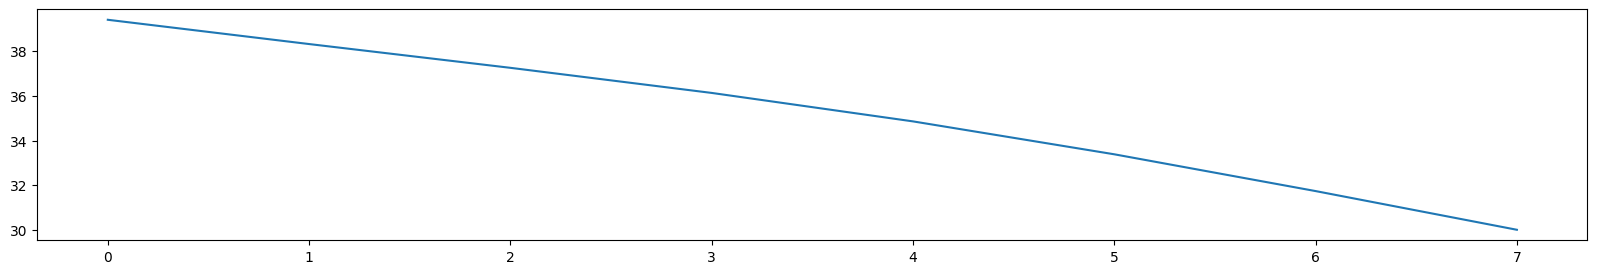

In [47]:
opt2.battery = [50]

# Configure battery start and ending level (for deadline hour)

start_level = 0.4
final_level = 0.6
battery_start = opt2.battery[0]*start_level
battery_final = opt2.battery[0]*final_level

deadline_hour = 8

print(battery_start,battery_final)

# Custom-built solver

class SolverExt(Solver):
    def battery_level(self, model, t):
        sun_t = self.predictor(self.sun, t, self.i, self.j)
        cons_t = self.predictor(self.cons, t, self.i, self.j)
        
        balance = sun_t*self.pv - cons_t + model.el_in[t] - model.el_out[t]
        if t == model.t0:
            return model.bat[t] == battery_start + balance
        return model.bat[t] == model.bat[t-1] + balance
        
    def _add_constraints(self):
        self.model.batlevel_cstr = Constraint(self.model.T, rule=self.battery_level)
        self.model.final_batlevel_cstr = Constraint(expr=self.model.bat[deadline_hour-1] >= battery_final)

# consider only the forecasted horizon window
opt3 = opt2.hours(t,t+deadline_hour) # nothing after deadline_hour should be optimize for

opt3.solver_class = SolverExt
opt3.optimize()

# plot the calculated behavior during the night (midnight to 8am)

plt.plot(opt3.bat)